In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Analysis on customer distribution and returning customers

Number of unique customers: 96096


/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/653986701.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_counts_by_state.index, y=customer_counts_by_state.values, palette='colorblind')


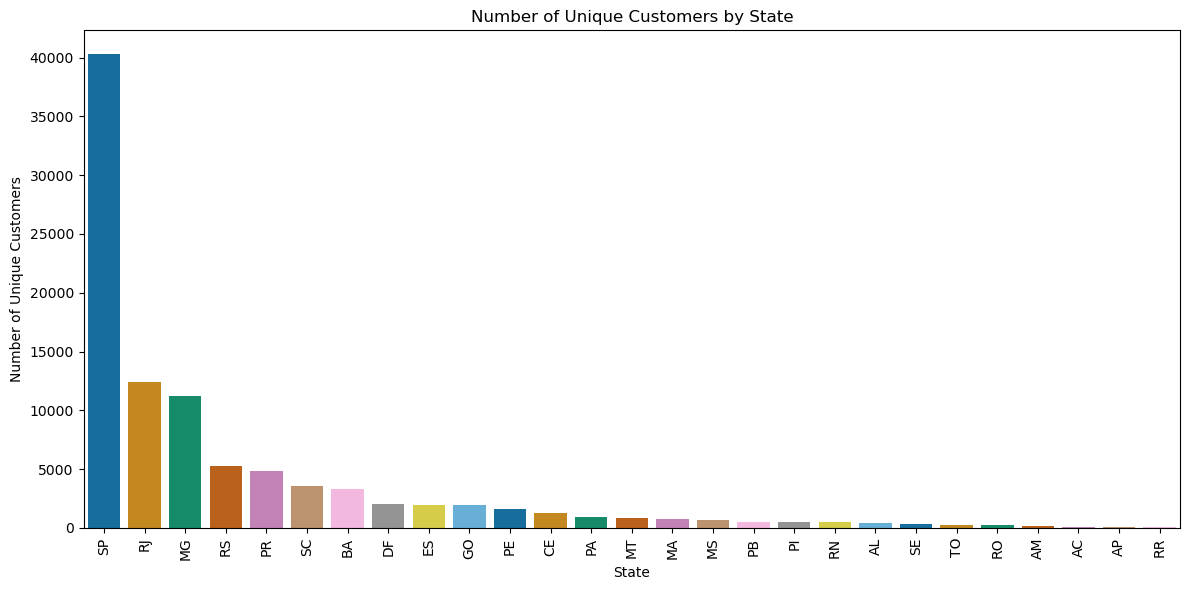

In [2]:
df_customers = pd.read_csv('../data/dim_customers.csv')

# Count the number of unique customers
num_customers = df_customers['customer_unique_id'].nunique()
print(f"Number of unique customers: {num_customers}")

# Compute the number of unique customers in differernt states and plot the distribution
customer_counts_by_state = df_customers.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=customer_counts_by_state.index, y=customer_counts_by_state.values, palette='colorblind')
plt.xticks(rotation=90)
plt.title('Number of Unique Customers by State')
plt.xlabel('State')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.show()

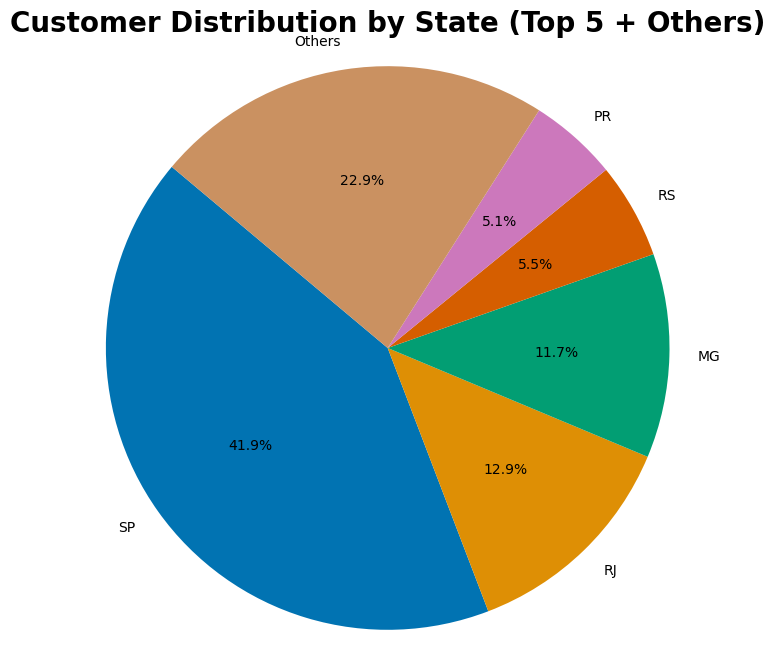

In [48]:
# Top 5 states + Others
top_5 = customer_counts_by_state.head(5)
others = customer_counts_by_state.iloc[5:].sum()

pie_data = pd.concat([top_5, pd.Series({'Others': others})])

plt.figure(figsize=(8, 8))
plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('colorblind', len(pie_data))
)
plt.title('Customer Distribution by State (Top 5 + Others)', fontsize=20, fontweight='bold')
plt.axis('equal')
plt.show()

> 1    2997
> 2     252
> 3      49
> 4      19
dtype: int64


/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/990251354.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


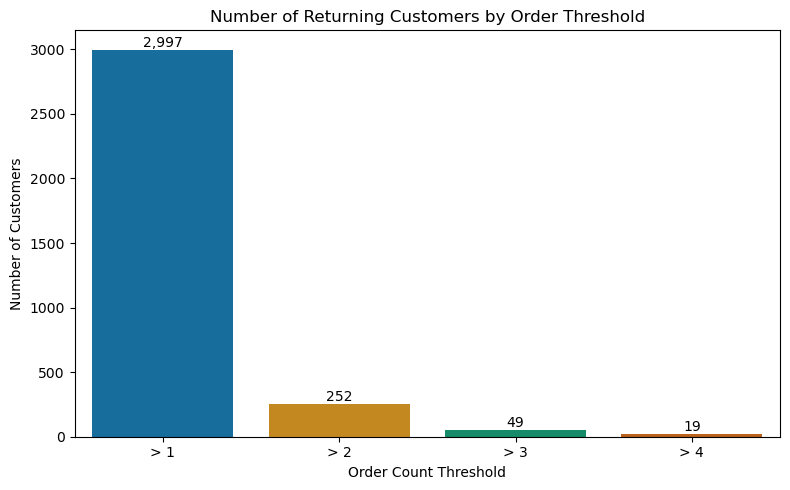

In [5]:
# Merge orders with customer unique IDs, then count orders per unique customer
df_orders = pd.read_csv('../data/fact_order.csv')

df = df_orders.merge(
    df_customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

order_counts = df.groupby('customer_unique_id')['order_id'].nunique()

# Absolute number of returning customers by threshold
thresholds = [1, 2, 3, 4]
returning_counts = pd.Series(
    {f'> {t}': (order_counts > t).sum() for t in thresholds}
)

print(returning_counts)

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=returning_counts.index,
    y=returning_counts.values,
    palette='colorblind'
)
ax.set_title('Number of Returning Customers by Order Threshold')
ax.set_xlabel('Order Count Threshold')
ax.set_ylabel('Number of Customers')

for i, v in enumerate(returning_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [6]:
num_of_customers = df_customers['customer_unique_id'].nunique()
print(f"Total number of unique customers: {num_of_customers}")
num_of_returning_customers = (order_counts > 1).sum()
print(f"Number of returning customers: {num_of_returning_customers}")

percentage_returning = (num_of_returning_customers / num_of_customers) * 100
print(f"Percentage of returning customers: {percentage_returning:.2f}%")


Total number of unique customers: 96096
Number of returning customers: 2997
Percentage of returning customers: 3.12%


In [8]:
num_of_customers_in_sp = df_customers[df_customers['customer_state'] == 'SP']['customer_unique_id'].nunique()
print(f"Number of unique customers in SP: {num_of_customers_in_sp}")

# 1. Get all customer records for SP
customers_sp = df_customers[df_customers['customer_state'] == 'SP']

# 2. Count orders per unique ID within that SP subset
sp_order_counts = customers_sp.groupby('customer_unique_id').size()

# 3. Count how many of those IDs appear more than once
num_of_returning_customers_in_sp = (sp_order_counts > 1).sum()

print(f"Number of returning customers in SP: {num_of_returning_customers_in_sp}")
percentage_returning_in_sp = (num_of_returning_customers_in_sp / num_of_customers_in_sp) * 100
print(f"Percentage of returning customers in SP: {percentage_returning_in_sp:.2f}%")


Number of unique customers in SP: 40302
Number of returning customers in SP: 1296
Percentage of returning customers in SP: 3.22%


## Observations on Returning Customers:
1. **Total Unique Customers**: There are a total of 96,000 unique customers in the dataset.
2. **Returning Customers**: Out of these, only 2997 customers have made more than one order, indicating that they are returning customers.
3. **Percentage of Returning Customers**: The percentage of returning customers is approximately 3.12%, which suggests that a small portion of the customer base is responsible for repeat purchases. 
This insight can be crucial for the business to understand customer loyalty and to strategize on how to increase the number of returning customers, potentially through targeted marketing campaigns or loyalty programs. 
4. **Customer Distribution**: Most of the customers are from Sao Paulo (SP), Rio de Janeiro (RJ), and Belo Horizonte (MG), which may indicate that these regions have a higher concentration of customers or better market penetration for the business. SP State population: 46,289,333, RJ State population: 17,366,189, MG State population: 21,411,923. This could be a factor in the higher number of customers from these states.

## Analysis on product categories and customer distribution

/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/1349979640.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


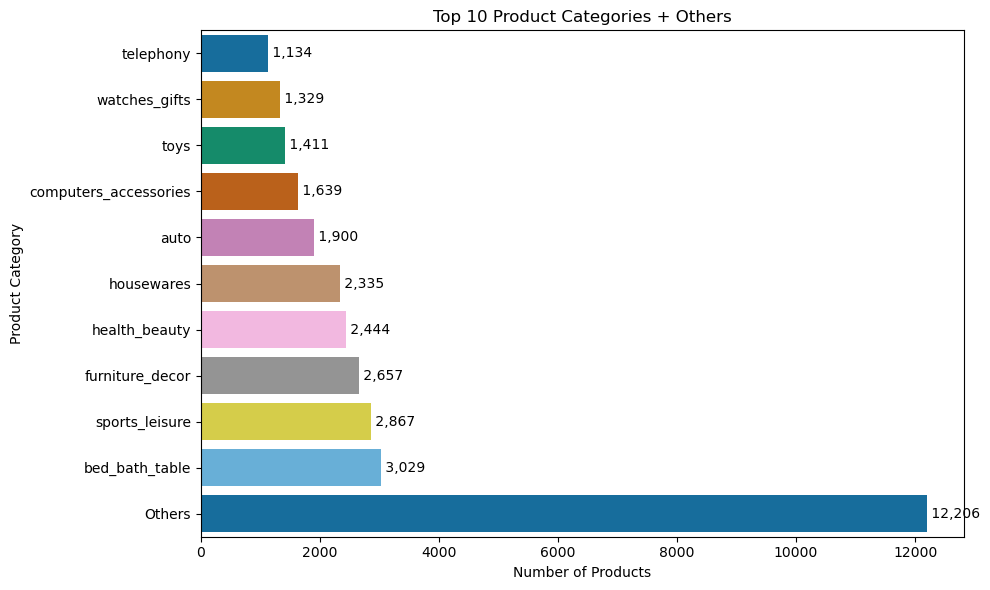

In [10]:
# Count products by category
df_products = pd.read_csv('../data/dim_products.csv')

product_counts = df_products['product_category_name'].value_counts()

# Top 10 + Others
top_10_products = product_counts.head(10)
others_products = product_counts.iloc[10:].sum()
plot_data_products = pd.concat([top_10_products, pd.Series({'Others': others_products})])

# Sort for horizontal plotting
plot_data_products = plot_data_products.sort_values()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=plot_data_products.values,
    y=plot_data_products.index,
    palette='colorblind'
)

ax.set_title('Top 10 Product Categories + Others')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Product Category')

for i, v in enumerate(plot_data_products.values):
    ax.text(v, i, f' {v:,}', va='center')

plt.tight_layout()
plt.show()

## Remapping product categories:
- The original dataset contains 71 unique product categories, which are poorly categorized and can be overwhelming for analysis. To simplify this, we can remap these categories into broader groups based on the type of products. For example:
- **Electronics**: Includes categories like "audio", "computers", "pc_gamers", etc. 
- **Music**: Includes categories like "musical_instruments", "cds_dvds_musicals", etc.
- **Fashion**: Includes categories like "fashio_female_clothing", "fashion_shoes", "fashion_sport", etc.   

/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/2346718587.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


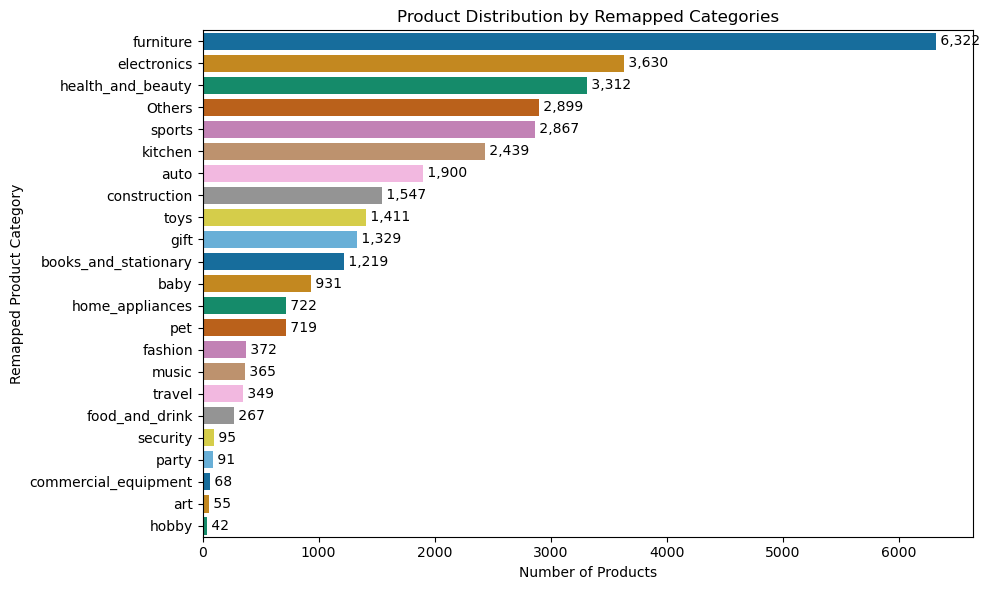

In [49]:
# 1. Define your "Golden" Categories
category_map = {
    'art': ['art', 'art_and_craftmanship'],
    'auto': ['auto'],
    'baby': ['baby', 'diapers_and_hygiene'],
    'commercial_equipment': ['industry_commerce_and_business'],
    'books_and_stationary': ['books_general_interest', 'books_imported', 'books_technical', 'stationery'],
    'construction': ['construction_tools_construction', 'construction_tools_lights', 'construction_tools_safety', 'construction_tools_garden', 
                     'construction_tools_tools', 'home_construction', 'garden_tools'],
    'electronics': ['air_conditioning', 'audio', 'computers', 'computers_accessories', 'console_games', 'electronics', 'fixed_telephony',
                    'pc_gamer', 'tablets_printing_image', 'telephony'],
    'fashion': ['fashio_female_clothing', 'fashion_bag_accessories', 'fashion_childrens_clothes', 'fashion_male_clothing', 
                'fashion_shoes', 'fashion_sport', 'fashion_underwear_beach'],
    'food_and_drink': ['drinks', 'food', 'food_drink'],
    'furniture': ['bed_bath_table', 'furniture_decor', 'furniture_bedroom', 'furniture_living_room', 'furniture_mattress_and_upholstery', 
                  'home_comfort_2', 'home_confort', 'office_furniture'],
    'gift': ['watches_gifts'],
    'health_and_beauty': ['health_beauty', 'perfumery'],
    'hobby': ['cine_photo', 'flowers'],
    'home_appliances': ['home_appliances', 'home_appliances_2', 'small_appliances', 'small_appliances_home_oven_and_coffee'],
    'kitchen': ['housewares', 'kitchen_dining_laundry_garden_furniture', 'la_cuisine'],
    'music': ['cds_dvds_musicals', 'dvds_blu_ray', 'music', 'musical_instruments'],
    'party': ['christmas_supplies', 'party_supplies'],
    'pet': ['pet_shop'],
    'security': ['security_and_services', 'signaling_and_security'],
    'sports': ['sports_leisure'],
    'toys': ['toys'],
    'travel': ['luggage_accessories']
    # Add 'Others' or 'Unclassified' for anything that doesn't fit
}

# 2. Transform a flat mapping for the categories
flat_category_map = {}
for clean_name, messy_list in category_map.items():
    for messy_name in messy_list:
        flat_category_map[messy_name] = clean_name

# 3. Apply the mapping
df_products['clean_category'] = df_products['product_category_name'].map(flat_category_map).fillna('Others')

# 4. Count the new categories
clean_category_counts = df_products['clean_category'].value_counts()

# Plot the new category distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=clean_category_counts.values,
    y=clean_category_counts.index,
    palette='colorblind'
)
ax.set_title('Product Distribution by Remapped Categories')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Remapped Product Category')
for i, v in enumerate(clean_category_counts.values):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()



In [23]:
# Top 10 sold product categories in SP, RJ, and MG (by number of order items)
df_order_items = pd.read_csv('../data/dim_order_item.csv')

target_states = ['SP', 'RJ', 'MG']

orders_with_state = (
	df_orders
	.merge(df_customers[['customer_id', 'customer_state']], on='customer_id', how='left')
)

sold_items = (
	df_order_items
	.merge(
		orders_with_state.loc[
			(orders_with_state['order_status'] == 'delivered') &
			(orders_with_state['customer_state'].isin(target_states)),
			['order_id', 'customer_state']
		],
		on='order_id',
		how='inner'
	)
	.merge(
		df_products[['product_id', 'clean_category']],
		on='product_id',
		how='left'
	)
)

top10_products_by_state = (
	sold_items
	.assign(product_category_name=lambda x: x['clean_category'].fillna('Unknown'))
	.groupby(['customer_state', 'product_category_name'])
	.size()
	.reset_index(name='units_sold')
	.sort_values(['customer_state', 'units_sold'], ascending=[True, False])
	.groupby('customer_state', as_index=False)
	.head(10)
)

for state in target_states:
	print(f"\nTop 10 products sold in {state}:")
	print(
		top10_products_by_state[top10_products_by_state['customer_state'] == state]
		.reset_index(drop=True)
	)


Top 10 products sold in SP:
  customer_state product_category_name  units_sold
0             SP             furniture        9754
1             SP           electronics        6190
2             SP     health_and_beauty        5569
3             SP                Others        3638
4             SP                sports        3576
5             SP               kitchen        3327
6             SP          construction        2423
7             SP                  gift        2234
8             SP                  auto        1716
9             SP                  toys        1674

Top 10 products sold in RJ:
  customer_state product_category_name  units_sold
0             RJ             furniture        3170
1             RJ           electronics        2016
2             RJ     health_and_beauty        1467
3             RJ                Others        1158
4             RJ                sports        1015
5             RJ               kitchen         891
6             RJ        

/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/943631009.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


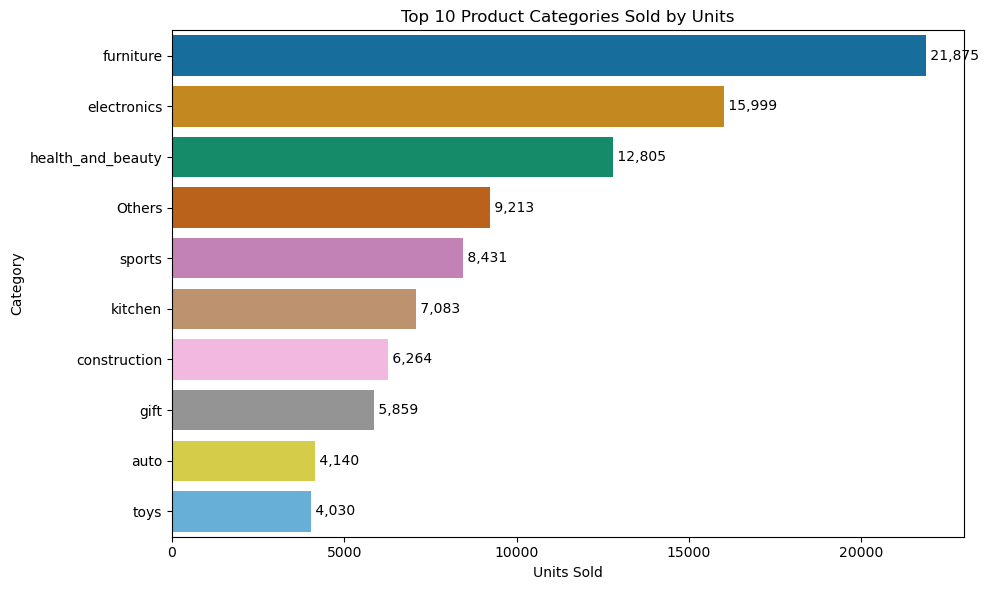

In [28]:
top_10_units = (
    df_order_items
    .merge(
        df_orders.loc[df_orders['order_status'] == 'delivered', ['order_id']],
        on='order_id',
        how='inner'
    )
    .merge(
        df_products[['product_id', 'clean_category']],
        on='product_id',
        how='left'
    )
    .assign(clean_category=lambda x: x['clean_category'].fillna('Others'))
    .groupby('clean_category')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=top_10_units.values,
    y=top_10_units.index,
    palette='colorblind'
)

ax.set_title('Top 10 Product Categories Sold by Units')
ax.set_xlabel('Units Sold')
ax.set_ylabel('Category')

for i, v in enumerate(top_10_units.values):
    ax.text(v, i, f' {v:,}', va='center')

plt.tight_layout()
plt.show()

In [26]:
# Revenue by clean category using price only (excluding freight_value)
revenue_by_category = (
    df_order_items
    .merge(df_products[['product_id', 'clean_category']], on='product_id', how='left')
    .assign(clean_category=lambda x: x['clean_category'].fillna('Others'))
    .groupby('clean_category', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'revenue_price_only'})
    .sort_values('revenue_price_only', ascending=False)
)

top_10_revenue = revenue_by_category.head(10)
print(top_10_revenue)

       clean_category  revenue_price_only
10          furniture          2193357.60
7         electronics          1793202.54
12  health_and_beauty          1657806.21
0              Others          1273426.21
11               gift          1205005.68
20             sports           988048.97
6        construction           794646.69
15            kitchen           680632.02
2                auto           592720.11
21               toys           483946.60


 year  total_revenue
 2016       49785.92
 2017     6155806.98
 2018     7386050.80


/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/306963032.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=revenue_by_year, x='year', y='total_revenue', palette='colorblind')


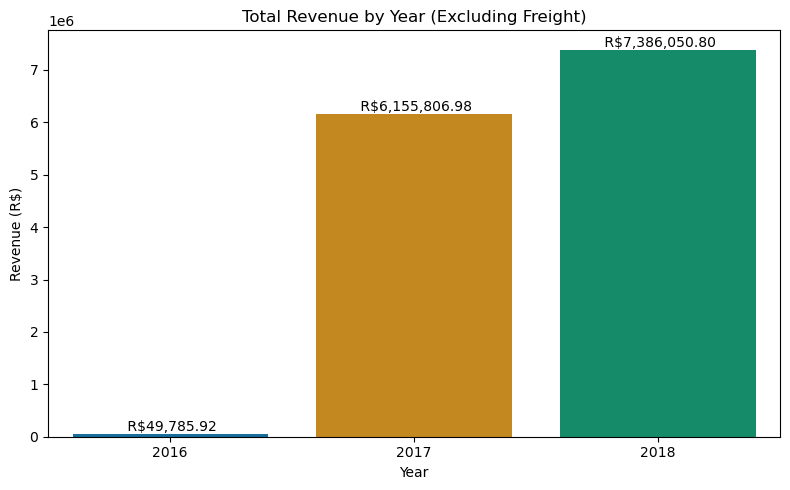

In [34]:
# Parse the order_purchase_timestamp and extract year
df_orders['year'] = pd.to_datetime(df_orders['order_purchase_timestamp']).dt.year

# Merge order items with orders to get the purchase year
revenue_by_year = (
    df_order_items
    .merge(
        df_orders[['order_id', 'year']],
        on='order_id',
        how='left'
    )
    .groupby('year')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'total_revenue'})
    .query('year in [2016, 2017, 2018]')
)

print(revenue_by_year.to_string(index=False))

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=revenue_by_year, x='year', y='total_revenue', palette='colorblind')
ax.set_title('Total Revenue by Year (Excluding Freight)')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (R$)')
for i, row in enumerate(revenue_by_year.itertuples()):
    ax.text(i, row.total_revenue, f' R${row.total_revenue:,.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/3937132938.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


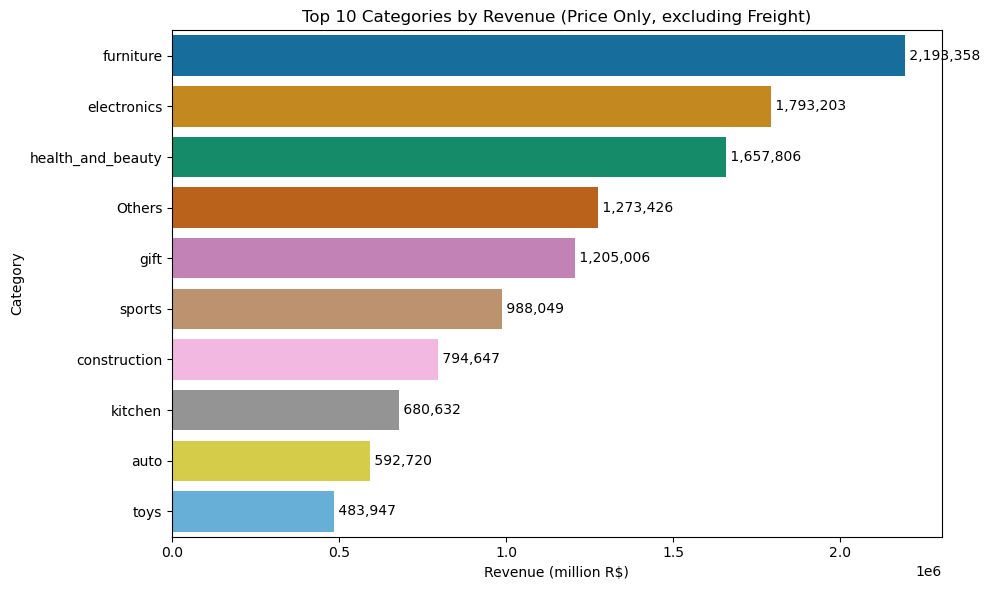

In [51]:
# Horizontal bar chart for top 10 revenue categories
plt.figure(figsize=(10, 6))
ax = sns.barplot(
	data=top_10_revenue.sort_values('revenue_price_only', ascending=False),
	x='revenue_price_only',
	y='clean_category',
	palette='colorblind'
)

ax.set_title('Top 10 Categories by Revenue (Price Only, excluding Freight)')
ax.set_xlabel('Revenue (million R$)')
ax.set_ylabel('Category')

for i, v in enumerate(top_10_revenue.sort_values('revenue_price_only', ascending=False)['revenue_price_only']):
	ax.text(v, i, f' {v:,.0f}', va='center')

plt.tight_layout()
plt.show()

In [35]:
# Revenue accumulation by month in 2018 (same definition as earlier: sum of item price)
orders_2018 = df_orders.copy()
orders_2018['order_purchase_timestamp'] = pd.to_datetime(
    orders_2018['order_purchase_timestamp'],
    utc=True
)
orders_2018 = orders_2018[orders_2018['order_purchase_timestamp'].dt.year == 2018]

monthly_revenue_2018 = (
    df_order_items
    .merge(orders_2018[['order_id', 'order_purchase_timestamp']], on='order_id', how='inner')
    .assign(month=lambda x: x['order_purchase_timestamp'].dt.to_period('M'))
    .groupby('month')['price']
    .sum()
    .sort_index()
    .rename('monthly_revenue')
    .reset_index()
)

monthly_revenue_2018['cumulative_revenue'] = monthly_revenue_2018['monthly_revenue'].cumsum()

target_revenue = 6_000_000
reached = monthly_revenue_2018[monthly_revenue_2018['cumulative_revenue'] >= target_revenue]

if not reached.empty:
    first_hit = reached.iloc[0]
    months_taken = int(first_hit['month'].month)  # from Jan to first hit month
    print(f"2018 took {months_taken} months to reach revenue of {target_revenue:,}.")
    print(f"Reached in: {first_hit['month']}")
    print(f"Cumulative revenue then: R${first_hit['cumulative_revenue']:,.2f}")
else:
    print(f"Revenue of {target_revenue:,} was not reached in 2018.")

2018 took 7 months to reach revenue of 6,000,000.
Reached in: 2018-07
Cumulative revenue then: R$6,531,219.47


/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/4041680022.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda x: x['order_purchase_timestamp'].dt.to_period('M'))


In [36]:
# 2018 data only covers Jan-Aug (Sep has only $145), so we project full year based on 8 months
revenue_2017 = revenue_by_year.loc[revenue_by_year['year'] == 2017, 'total_revenue'].values[0]
revenue_2018_actual = revenue_by_year.loc[revenue_by_year['year'] == 2018, 'total_revenue'].values[0]

# Project 2018 full year based on 8 complete months (exclude Sep which is incomplete)
revenue_2018_8months = monthly_revenue_2018[monthly_revenue_2018['month'].astype(str) != '2018-09']['monthly_revenue'].sum()
revenue_2018_projected = revenue_2018_8months / 8 * 12

actual_growth = (revenue_2018_actual - revenue_2017) / revenue_2017 * 100
projected_growth = (revenue_2018_projected - revenue_2017) / revenue_2017 * 100

print(f"2017 Total Revenue:               R${revenue_2017:>15,.2f}")
print(f"2018 Actual Revenue (partial):    R${revenue_2018_actual:>15,.2f}")
print(f"2018 Projected Revenue (full yr): R${revenue_2018_projected:>15,.2f}")
print(f"\nActual Growth Rate (partial):     {actual_growth:>8.2f}%")
print(f"Projected Growth Rate (full yr):  {projected_growth:>8.2f}%")

2017 Total Revenue:               R$   6,155,806.98
2018 Actual Revenue (partial):    R$   7,386,050.80
2018 Projected Revenue (full yr): R$  11,078,858.70

Actual Growth Rate (partial):        19.99%
Projected Growth Rate (full yr):     79.97%


In [40]:
# Unique customers by year (2016, 2017, 2018)
orders_with_customer = df_orders.merge(
	df_customers[['customer_id', 'customer_unique_id']],
	on='customer_id',
	how='left'
).copy()

orders_with_customer['order_purchase_timestamp'] = pd.to_datetime(
	orders_with_customer['order_purchase_timestamp'],
	utc=True
)
orders_with_customer['year'] = orders_with_customer['order_purchase_timestamp'].dt.year

unique_customers_by_year = (
	orders_with_customer[orders_with_customer['year'].isin([2016, 2017, 2018])]
	.groupby('year')['customer_unique_id']
	.nunique()
	.sort_index()
)

print("Unique customers by year:")
print(unique_customers_by_year.to_string())

# Growth: 2017 -> 2018 (partial actual)
cust_2017 = unique_customers_by_year.loc[2017]
cust_2018_partial = unique_customers_by_year.loc[2018]
growth_partial = (cust_2018_partial - cust_2017) / cust_2017 * 100

# Growth: 2017 -> 2018 (projected full year)
customers_2018 = orders_with_customer[orders_with_customer['year'] == 2018].copy()
customers_2018['month'] = customers_2018['order_purchase_timestamp'].dt.to_period('M')

monthly_unique_2018 = (
	customers_2018.groupby('month')['customer_unique_id']
	.nunique()
	.sort_index()
)

# Exclude Sep-2018 as incomplete (consistent with your earlier revenue projection logic)
monthly_unique_2018_complete = monthly_unique_2018[monthly_unique_2018.index.astype(str) != '2018-09']
cust_2018_projected_full = monthly_unique_2018_complete.mean() * 12
growth_full = (cust_2018_projected_full - cust_2017) / cust_2017 * 100

print(f"\n2017 unique customers: {cust_2017:,}")
print(f"2018 unique customers (partial): {cust_2018_partial:,}")
print(f"Growth rate 2017 -> 2018 (partial): {growth_partial:.2f}%")

print(f"\n2018 projected unique customers (full year): {cust_2018_projected_full:,.0f}")
print(f"Growth rate 2017 -> 2018 (projected full year): {growth_full:.2f}%")

Unique customers by year:
year
2016      326
2017    43713
2018    52749

2017 unique customers: 43,713
2018 unique customers (partial): 52,749
Growth rate 2017 -> 2018 (partial): 20.67%

2018 projected unique customers (full year): 71,157
Growth rate 2017 -> 2018 (projected full year): 62.78%


/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/3550184662.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  customers_2018['month'] = customers_2018['order_purchase_timestamp'].dt.to_period('M')


In [37]:
# Count unique sellers by cleaned product category
seller_counts_by_category = (
    df_order_items
    .merge(df_products[['product_id', 'clean_category']], on='product_id', how='left')
    .assign(clean_category=lambda x: x['clean_category'].fillna('Others'))
    .groupby('clean_category')['seller_id']
    .nunique()
    .sort_values(ascending=False)
    .rename('num_unique_sellers')
)

print(seller_counts_by_category)

clean_category
Others                  747
furniture               600
health_and_beauty       580
kitchen                 501
electronics             499
sports                  481
construction            411
auto                    383
baby                    252
toys                    252
books_and_stationary    241
home_appliances         164
pet                     137
food_and_drink          114
gift                    101
music                    91
travel                   73
fashion                  51
security                 47
art                      36
commercial_equipment     29
party                    28
hobby                    17
Name: num_unique_sellers, dtype: int64


/var/folders/vf/p6tql7n155x4cbnbq23vqytr0000gn/T/ipykernel_57504/114408145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


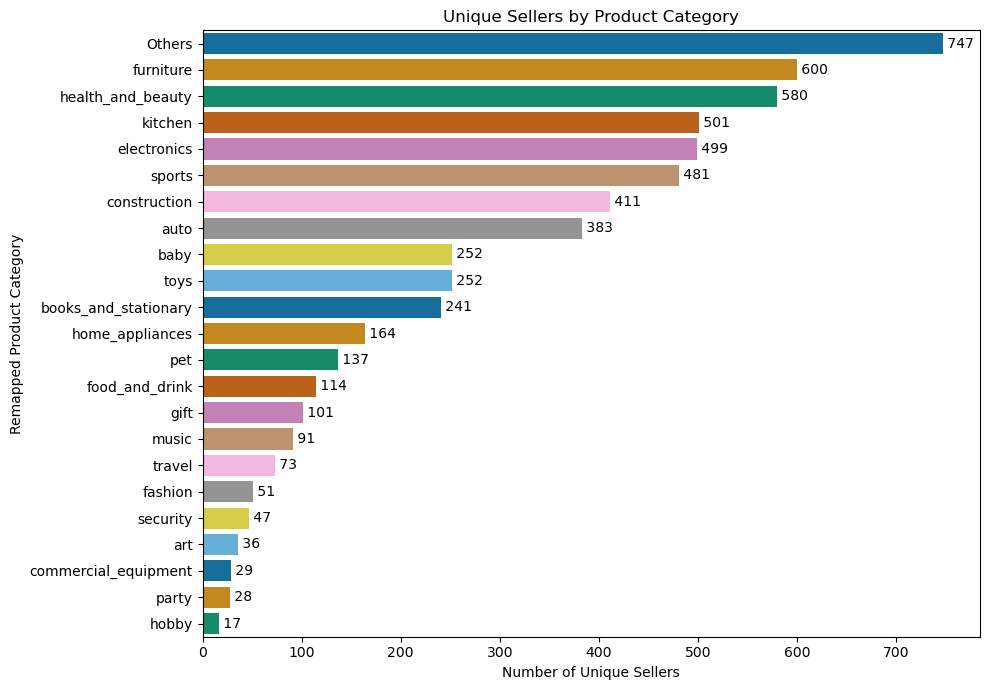

In [50]:
plt.figure(figsize=(10, 7))
ax = sns.barplot(
	x=seller_counts_by_category.values,
	y=seller_counts_by_category.index,
	palette='colorblind'
)

ax.set_title('Unique Sellers by Product Category')
ax.set_xlabel('Number of Unique Sellers')
ax.set_ylabel('Remapped Product Category')

for i, v in enumerate(seller_counts_by_category.values):
	ax.text(v, i, f' {v}', va='center')

plt.tight_layout()
plt.show()

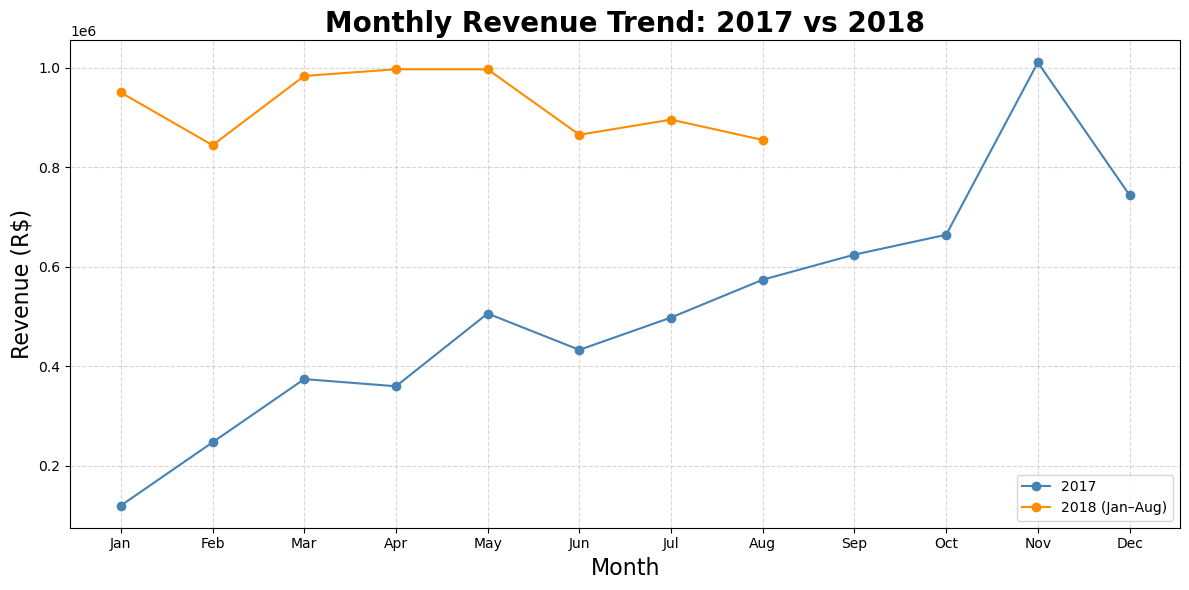

In [44]:
# Monthly revenue for 2017
orders_2017 = df_orders.copy()
orders_2017['order_purchase_timestamp'] = pd.to_datetime(orders_2017['order_purchase_timestamp'], utc=True)
orders_2017 = orders_2017[orders_2017['order_purchase_timestamp'].dt.year == 2017]

monthly_revenue_2017 = (
    df_order_items
    .merge(orders_2017[['order_id', 'order_purchase_timestamp']], on='order_id', how='inner')
    .assign(month=lambda x: x['order_purchase_timestamp'].dt.month)
    .groupby('month')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'monthly_revenue'})
)

# Combine 2017 and 2018 monthly revenues (exclude Sep 2018 as incomplete)
monthly_revenue_2018_clean = monthly_revenue_2018[monthly_revenue_2018['month'].astype(str) != '2018-09'].copy()
monthly_revenue_2018_clean['month_num'] = monthly_revenue_2018_clean['month'].dt.month

combined = pd.DataFrame({
    'month': range(1, 13),
    '2017': monthly_revenue_2017.set_index('month')['monthly_revenue']
})
combined['2018'] = monthly_revenue_2018_clean.set_index('month_num')['monthly_revenue']

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.plot(combined['month'], combined['2017'], marker='o', label='2017', color='steelblue')
plt.plot(combined['month'], combined['2018'], marker='o', label='2018 (Jan–Aug)', color='darkorange')

plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.title('Monthly Revenue Trend: 2017 vs 2018', fontsize=20, fontweight='bold')
plt.xlabel('Month', fontsize=16)
plt.ylabel('Revenue (R$)', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()